### Imports for Python

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, optimize
import re

### Helping Function as ROI and Path Loading 

In [13]:
def load_file(file_path):
    """Load beta spectroscopy MCA data file.
    Returns: (channel_array, counts_array)
    """
    text = Path(file_path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []
    
    for line in text:
        # Try to parse as channel/count pair (format: channel, count)
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)


def calcular_centroide(canais, contagens):
    """Calculate centroid (weighted average) of a peak."""
    canais = np.array(canais)
    contagens = np.array(contagens)
    
    if np.sum(contagens) == 0:
        return 0, 0
        
    centroid = np.sum(canais * contagens) / np.sum(contagens)
    # Estimate sigma from peak width
    sigma = np.sqrt(np.sum((canais - centroid)**2 * contagens) / np.sum(contagens))
    
    return centroid, sigma

def plots(x, y, tipo="line", titulo=None, xlabel=None, ylabel=None, label=None, 
          color=None, marker=None, grid=False, y_scale="linear", figsize=(10, 6), legend=False,
          preencher_roi=None, label_roi=None, color_roi="orange", alpha_roi=0.3,
          linha_vertical=None, label_linha=None, color_linha="red", linestyle=None):
    """
    Função Geral para Geração de Gráficos (Matplotlib)
    
    Parâmetros:
    -----------
    x, y : array-like ou lista de arrays
        Dados dos eixos X e Y. Podem ser listas para desenhar múltiplas curvas.
    tipo : str ou lista de str, default="line"
        Tipo de gráfico para cada curva: "line" (linha) ou "scatter" (pontos dispersos).
    titulo : str, optional
        Título principal do gráfico.
    xlabel, ylabel : str, optional
        Rótulos (labels) dos eixos X e Y.
    label : str ou lista de str, optional
        Legenda correspondente a cada curva.
    color : str ou lista de str, optional
        Cor de cada curva (ex: "darkblue", "crimson", "orange").
    marker : str ou lista de str, optional
        Símbolo dos pontos de cada curva (ex: "o", "x", "^", "s").
    grid : bool, default=False
        Se True, ativa a grelha de fundo no gráfico.
    y_scale : str, default="linear"
        Escala do eixo Y: "linear" ou "log".
    figsize : tuple, default=(10, 6)
        Dimensões da figura/janela gráfica (largura, altura).
    legend : bool, default=False
        Se True, força a exibição da caixa de legendas.
    preencher_roi : tuple, optional
        Par de canais (c_min, c_max) para preencher a área sob a curva (Região de Interesse).
    label_roi : str, optional
        Texto de legenda para a área preenchida da ROI.
    color_roi : str, default="orange"
        Cor do preenchimento da ROI.
    alpha_roi : float, default=0.3
        Opacidade/transparência do preenchimento da ROI (0 a 1).
    linha_vertical : float, optional
        Coordenada X onde será desenhada uma linha vertical tracejada (ex: centroide).
    label_linha : str, optional
        Texto de legenda para a linha vertical.
    color_linha : str, default="red"
        Cor da linha vertical.
    linestyle : str ou lista de str, optional
        Estilo de linha para cada curva (ex: "-" para contínua, "--" para tracejada).
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Garantir que as entradas são tratadas como listas para suportar múltiplas curvas
    x_list = x if isinstance(x, list) else [x]
    y_list = y if isinstance(y, list) else [y]
    tipo_list = tipo if isinstance(tipo, list) else [tipo] * len(x_list)
    label_list = label if isinstance(label, list) else [label] * len(x_list)
    color_list = color if isinstance(color, list) else [None] * len(x_list)
    marker_list = marker if isinstance(marker, list) else [None] * len(x_list)
    
    # Configuração dos estilos de linha individuais
    if linestyle is None:
        ls_list = ["-"] * len(x_list)
    else:
        ls_list = linestyle if isinstance(linestyle, list) else [linestyle] * len(x_list)
        
    # Construção de cada curva no gráfico
    for i in range(len(x_list)):
        t = tipo_list[i] if i < len(tipo_list) else tipo_list[-1]
        lbl = label_list[i] if i < len(label_list) else None
        c = color_list[i] if i < len(color_list) else None
        m = marker_list[i] if i < len(marker_list) else None
        ls = ls_list[i] if i < len(ls_list) else "-"
        
        # Generalização das Camadas (zorder):
        # Linhas ficam sempre atrás (zorder=2) e pontos (scatter) saltam sempre para a frente (zorder=3)
        if t == "line":
            ax.plot(x_list[i], y_list[i], label=lbl, color=c, marker=m, linestyle=ls, zorder=2)
        elif t == "scatter":
            ax.scatter(x_list[i], y_list[i], label=lbl, color=c, marker=m, zorder=3)
            
    # Preenchimento da Região de Interesse (ROI) - Apenas se houver uma única curva principal
    if preencher_roi and len(x_list) == 1:
        mask = (x_list[0] >= preencher_roi[0]) & (x_list[0] <= preencher_roi[1])
        ax.fill_between(x_list[0], y_list[0], where=mask, color=color_roi, alpha=alpha_roi, label=label_roi, zorder=1)
        
    # Adição de Linha Vertical (ex: Posição do Centroide)
    if linha_vertical:
        ax.axvline(x=linha_vertical, color=color_linha, linestyle="--", label=label_linha, zorder=1)
        
    # Formatação final dos eixos e elementos visuais
    ax.set_yscale(y_scale)
    if titulo: ax.set_title(titulo)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if grid: ax.grid(True, which="both", linestyle=":", alpha=0.6, zorder=0) # Grelha no fundo absoluto
    if legend or label: ax.legend()
    
    plt.show()
    
    plt.show()

### Centroide do Césio
Nota importante $\sigma$ estamos a calcular desvio padrão, $$\sigma = \sqrt{\frac{\sum (C_i - \mu)^2 \cdot N_i}{\sum N_i}}$$ e enquanto o Erro Padrão $$\sigma_{Erro Padrão} = \frac{\sigma}{\sqrt{N}}$$ 

Centroide: 113.51 | Erro Padrão: 0.048999 | σ: 5.28 | FWHM: 12.44
-> Valores do Césio guardados com sucesso!


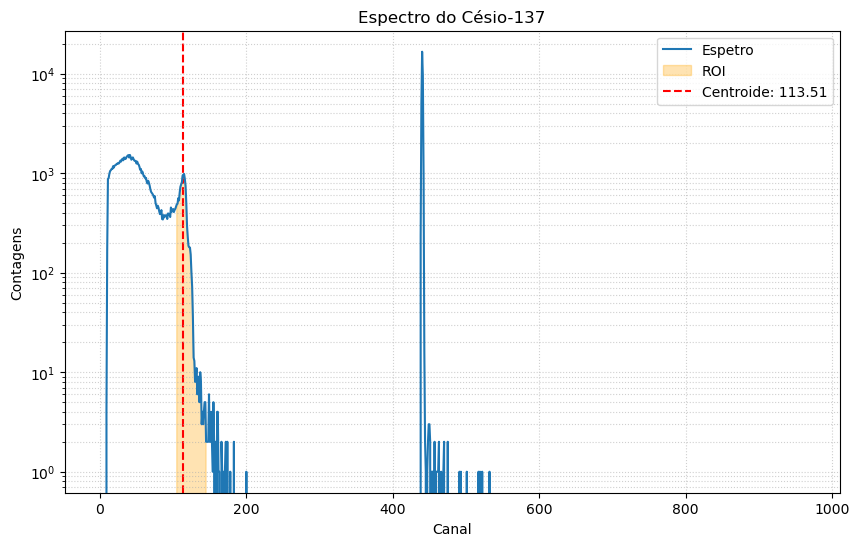

In [14]:
arquivo_cesio = 'CPR1.asc'

centroide_cs_ant = None
sigma_cs_ant = None

try:
    canais, contagens = load_file(arquivo_cesio)

    c_min, c_max = 105, 145 
    mascara = (canais >= c_min) & (canais <= c_max)
    
    # Dados na ROI
    c_roi = canais[mascara]
    n_roi = contagens[mascara]
    
    centroide, sigma = calcular_centroide(c_roi, n_roi)
    
    # Cálculo do erro padrão do centroide
    erro_padrao = sigma / np.sqrt(np.sum(n_roi))
    
    centroide_cs_ant = centroide
    sigma_cs_ant = sigma
    
    print(f"Centroide: {centroide:.2f} | Erro Padrão: {erro_padrao:.6f} | \u03c3: {sigma:.2f} | FWHM: {2.355 * sigma:.2f}")
    print("-> Valores do Césio guardados com sucesso!")

    plots(
        x=canais,
        y=contagens,
        tipo="line",
        titulo="Espectro do Césio-137",
        xlabel="Canal",
        ylabel="Contagens",
        label="Espetro",
        color="darkblue",
        grid=True,
        y_scale="log",
        preencher_roi=(c_min, c_max),
        label_roi="ROI",
        color_roi="orange",
        linha_vertical=centroide,
        label_linha=f"Centroide: {centroide:.2f}",
        color_linha="red"
    )

except FileNotFoundError:
    print(f"Ficheiro '{arquivo_cesio}' não encontrado.")

### Reta de Calibração com Pulsers de Referencia

Para isto foi usado a seguinte formula para o qui-quadrado: $$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$$




--- 1. Estatística dos Picos (Pulsers) ---
Pulser02.asc -> Centroide: 41.38 | σ (Largura): 0.9566 | Erro Padrão: 0.023715
Pulser04.asc -> Centroide: 86.95 | σ (Largura): 2.5865 | Erro Padrão: 0.064065
Pulser06.asc -> Centroide: 129.62 | σ (Largura): 0.7681 | Erro Padrão: 0.019043
Pulser08.asc -> Centroide: 172.41 | σ (Largura): 2.6267 | Erro Padrão: 0.065101
Pulser10.asc -> Centroide: 217.78 | σ (Largura): 4.9831 | Erro Padrão: 0.123463
Pulser12.asc -> Centroide: 263.35 | σ (Largura): 5.6824 | Erro Padrão: 0.140789

--- 2. Dados de Referência (Césio-137) ---
Recuperado -> Centroide: 113.51 | σ (Largura): 5.2807 | Erro Padrão: 0.048999

--- 3. Resultados Finais do Ajuste ---
Reta Final: E = 0.005700 * C + (0.014685)
Incerteza do declive (dm): 2.594044e-05
Incerteza da ordenada (db): 2.915996e-03
Qui-Quadrado Reduzido (χ²_red): 2.496231e+02
R²: 0.999822

-> Dados da calibração e erros guardados com sucesso!


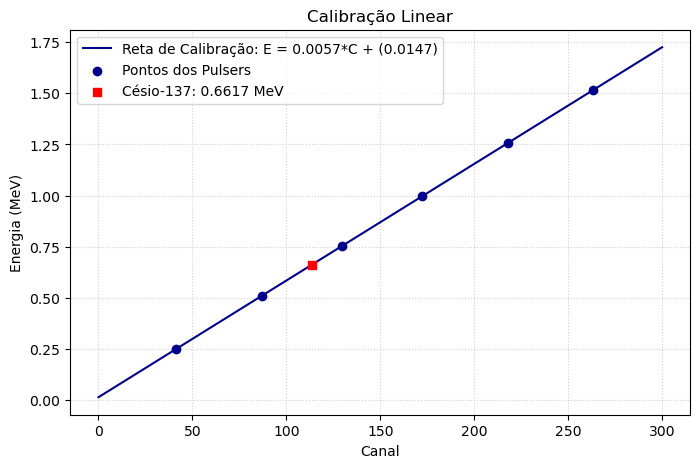

In [15]:
# 1. DADOS DOS FICHEIROS DOS PULSERS
dados_arquivos = {
    'Pulser02.asc': (0,1024), 'Pulser04.asc': (0,1024), 'Pulser06.asc': (0,1024),
    'Pulser08.asc': (0,1024), 'Pulser10.asc': (0,1024), 'Pulser12.asc': (0,1024)
}

centroides_p = []
erros_centroide_p = []

print("--- 1. Estatística dos Picos (Pulsers) ---")
for arquivo, (c_min, c_max) in dados_arquivos.items():
    try:
        canais, contagens = load_file(arquivo)
        mascara = (canais >= c_min) & (canais <= c_max)
        
        c_roi, n_roi = canais[mascara], contagens[mascara]
        centroide_pulser, sigma_pulser = calcular_centroide(c_roi, n_roi)
        
        # Erro padrão da posição do centroide
        erro_c = sigma_pulser / np.sqrt(np.sum(n_roi))
        
        centroides_p.append(centroide_pulser)
        erros_centroide_p.append(erro_c)
        
        print(f"{arquivo} -> Centroide: {centroide_pulser:.2f} | \u03c3 (Largura): {sigma_pulser:.4f} | Erro Padrão: {erro_c:.6f}")
    except FileNotFoundError:
        print(f"Ficheiro {arquivo} não encontrado.")


# 2. RECUPERAR DADOS DO CÉSIO-137 
print("\n--- 2. Dados de Referência (Césio-137) ---")
try:
    centroide_cs = centroide_cs_ant
    sigma_cs = sigma_cs_ant
    erro_cs = erro_padrao if 'erro_padrao' in globals() else sigma_cs / 100  
    energia_cs = 0.6617  # MeV
    
    print(f"Recuperado -> Centroide: {centroide_cs:.2f} | \u03c3 (Largura): {sigma_cs:.4f} | Erro Padrão: {erro_cs:.6f}")

    # 3. AJUSTE DA RETA DA ESCALA PROPORCIONAL (Pulsers)
    x_p = np.array(centroides_p)
    y_nom = np.arange(0.2, 1.3, 0.2) 
    
    pesos = 1.0 / np.array(erros_centroide_p)
    
    # Extração da matriz de covariância (cov=True) para calcular as incertezas estatísticas
    popt, pcov = np.polyfit(x_p, y_nom, 1, w=pesos, cov=True) # a diagonal das cov contém as variâncias dos parâmetros ajustados
    m_prop, b_prop = popt[0], popt[1]

    # Uso do Césio como referencia 
    valor_nom_cs = m_prop * centroide_cs + b_prop
    fator_correcao = energia_cs / valor_nom_cs

    # ====== VARIÁVEIS GLOBAIS GUARDADAS COM ERROS ======
    m_real = m_prop * fator_correcao
    b_real = b_prop * fator_correcao
    
    # Incertezas absolutas do ajuste propagadas com o fator de escala
    dm_real = np.sqrt(pcov[0, 0]) * fator_correcao
    db_real = np.sqrt(pcov[1, 1]) * fator_correcao
    # =========================================================================

    # Preparação correta dos dados e da linha para o gráfico
    energias_reais_p = m_real * x_p + b_real
    erros_energia_p = np.array(erros_centroide_p) * m_real
    
    # Gerar uma reta contínua ideal para o gráfico (visto que popt une pontos)
    c_reta = np.linspace(0, 300, 100)
    e_reta = m_real * c_reta + b_real
    
    # ====== ESTATÍSTICA: R2 e QUI-QUADRADO ======
    y_dados = y_nom * fator_correcao
    ss_res = np.sum((y_dados - energias_reais_p) ** 2)
    ss_tot = np.sum((y_dados - np.mean(y_dados)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    residuos = ((y_dados - energias_reais_p) ** 2) / (erros_energia_p ** 2)
    qui_quadrado_red = np.sum(residuos) / (len(x_p) - 2)

    print("\n--- 3. Resultados Finais do Ajuste ---")
    print(f"Reta Final: E = {m_real:.6f} * C + ({b_real:.6f})")
    print(f"Incerteza do declive (dm): {dm_real:.6e}")
    print(f"Incerteza da ordenada (db): {db_real:.6e}")
    print(f"Qui-Quadrado Reduzido (\u03c7\u00b2_red): {qui_quadrado_red:.6e}")
    print(f"R\u00b2: {r_squared:.6f}")
    print("\n-> Dados da calibração e erros guardados com sucesso!")

    # Organização das listas: c_reta (fundo) -> x_p (meio) -> Césio (frente absoluta)
    plots(
        x=[c_reta, x_p, np.array([centroide_cs])], 
        y=[e_reta, energias_reais_p, np.array([energia_cs])], 
        tipo=["line", "scatter", "scatter"],
        titulo="Calibração Linear", 
        xlabel="Canal", 
        ylabel="Energia (MeV)", 
        label=[
            f"Reta de Calibração: E = {m_real:.4f}*C + ({b_real:.4f})", 
            "Pontos dos Pulsers",
            f"Césio-137: {energia_cs} MeV"
        ], 
        color=["darkblue", "darkblue", "red"],
        marker=[None, "o", "s"],
        grid=True,
        figsize=(8, 5),
        legend=True
    )

except NameError:
    print("\nERRO: Corre primeiro o código do Césio e guarda as variáveis necessárias.")

Coisa feita pelo gemini parace fazer sentido os valora tabealdo de G parecem certo mas tenho de reconfimar a os erros do paramentros ta correto qui quadrado paraece usar a formula certa o valor obtido parece bom por isso so falta reconfirmar e confiamar a janela


--- 3. Limite Cinemático (Tl-204) ---
Reta do Kurie Plot: y = -3.3546 * E + (2.7106)
Ponto de Fim Experimental (E0): 0.8080 ± 0.0248 MeV
Qui-Quadrado Reduzido (χ²_red): 8.237959e-01
R²: 0.966774


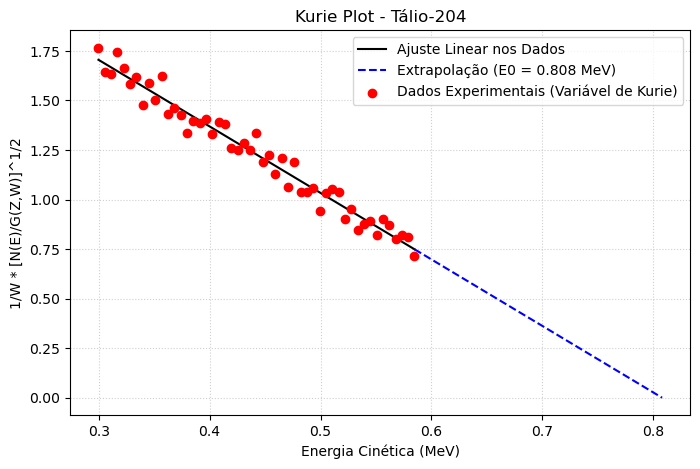

In [16]:
# Tabela 5.3: Valores de P e G(Z,W) para o Tl-204 (Dados do PDF de apoio)
P_tab = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
G_tab = np.array([28.26, 28.19, 27.99, 27.67, 27.25, 26.76, 26.23, 25.66, 25.09, 24.53, 23.98, 22.95, 22.01, 21.17, 20.41, 19.72, 19.10, 18.54])

try:
    # 1. Carregar dados do Tálio-204
    canais, contagens = load_file('TLSINV.asc')
    
    # Janela para o ajuste linear da reta de Kurie (ajustar c_min e c_max se necessário olhando para o vosso espetro)
    c_min, c_max = 50, 100 
    mascara = (canais >= c_min) & (canais <= c_max)
    
    C_fit = canais[mascara]
    N_E = contagens[mascara]

    # 2. Transformações cinemáticas relativistas usando a calibração importada
    E = m_real * C_fit + b_real   # Energia cinética K (MeV)
    W = (E / 0.511) + 1            # Energia total adimensional W
    P = np.sqrt(W**2 - 1)          # Momento adimensional P
    
    # Interpolação para obter os valores contínuos da função de Fermi G(Z,W)
    G = np.interp(P, P_tab, G_tab)

    # 3. Cálculo da Variável de Kurie (A fórmula exata fornecida)
    y_kurie = (1 / W) * np.sqrt(N_E / G)

    # 4. Ajuste Linear no Kurie Plot (y = m_k * E + b_k) com extração de covariâncias
    popt_k, pcov_k = np.polyfit(E, y_kurie, 1, cov=True)
    m_k, b_k = popt_k[0], popt_k[1]
    
    # Limite cinemático (End-point onde a reta interseta o eixo horizontal, y = 0)
    E0 = -b_k / m_k                

    # ====== PROPAGAÇÃO DE ERROS PARA ENCONTRAR A INCERTEZA DO E0 ======
    # Erros do próprio ajuste linear do Kurie Plot
    dm_k = np.sqrt(pcov_k[0, 0])
    db_k = np.sqrt(pcov_k[1, 1])
    
    # Incerteza estatística associada ao ajuste da reta de Kurie
    erro_E0_ajuste = abs(E0) * np.sqrt((db_k / b_k)**2 + (dm_k / m_k)**2)
    
    # Incerteza sistemática vinda da escala de calibração original (m_real e b_real)
    erro_escala_calibracao = abs(E0) * (dm_real / m_real)
    
    # Incerteza total combinada do E0
    incerteza_E0 = np.sqrt(erro_E0_ajuste**2 + erro_escala_calibracao**2)
    # ==================================================================

    # ====== ESTATÍSTICA: R2 e QUI-QUADRADO DO VALOR DE KURIE ======
    y_pred = m_k * E + b_k
    
    # Coeficiente de Determinação R²
    ss_res = np.sum((y_kurie - y_pred) ** 2)
    ss_tot = np.sum((y_kurie - np.mean(y_kurie)) ** 2)
    r_squared_k = 1 - (ss_res / ss_tot)
    
    # Propagação do erro estatístico de Poisson de N_E para a variável y_kurie
    # Como y = (1/W) * sqrt(N/G), o desvio padrão de y devido a sigma_N = sqrt(N) é:
    # dy = y * 0.5 * (sigma_N / N) = y / (2 * sqrt(N))
    erros_y_kurie = y_kurie / (2 * np.sqrt(N_E))
    
    # Qui-Quadrado Reduzido (graus de liberdade = N_pontos - 2 parâmetros do ajuste)
    residuos_k = ((y_kurie - y_pred) ** 2) / (erros_y_kurie ** 2)
    qui_quadrado_red_k = np.sum(residuos_k) / (len(E) - 2)
    # ==================================================================

    print(f"--- 3. Limite Cinemático (Tl-204) ---")
    print(f"Reta do Kurie Plot: y = {m_k:.4f} * E + ({b_k:.4f})")
    print(f"Ponto de Fim Experimental (E0): {E0:.4f} ± {incerteza_E0:.4f} MeV")
    print(f"Qui-Quadrado Reduzido (\u03c7\u00b2_red): {qui_quadrado_red_k:.6e}")
    print(f"R\u00b2: {r_squared_k:.6f}")

    # 5. Preparar os troços da reta para o gráfico
    # Linha contínua sobre a região de pontos ajustados
    E_solida = np.linspace(E.min(), E.max(), 50)
    y_solida = m_k * E_solida + b_k

    # Linha tracejada extrapolando os dados até cruzar o eixo X no ponto E0
    E_tracejada = np.linspace(E.max(), E0, 50)
    y_tracejada = m_k * E_tracejada + b_k

    # 6. Desenhar o gráfico usando a função geral plots
    plots(
        x=[E_solida, E_tracejada, E], 
        y=[y_solida, y_tracejada, y_kurie], 
        tipo=["line", "line", "scatter"],   
        linestyle=["-", "--", None],         
        titulo="Kurie Plot - Tálio-204", 
        xlabel="Energia Cinética (MeV)", 
        ylabel="1/W * [N(E)/G(Z,W)]^1/2", 
        label=[
            "Ajuste Linear nos Dados", 
            f"Extrapolação (E0 = {E0:.3f} MeV)",
            "Dados Experimentais (Variável de Kurie)"
        ], 
        color=["black", "blue", "red"],
        marker=[None, None, "o"],
        grid=True,
        figsize=(8, 5),
        legend=True
    )

except NameError:
    print("ERRO: Garante que corres primeiro o código dos Pulsers para definir 'm_real', 'b_real' e os seus respetivos erros.")
except FileNotFoundError:
    print("ERRO: Ficheiro 'TLSINV.asc' não encontrado no diretório atual.")